<a href="https://www.kaggle.com/code/lalit7881/internship-selection-prediction-eda?scriptVersionId=318841581" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aiexplorer77/internship-selection-prediction-dataset/Internship_Selection_Dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/aiexplorer77/internship-selection-prediction-dataset/Internship_Selection_Dataset.csv")

In [3]:
df.head()

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,...,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,1,6.87,7,0,0,4,3,2,7,Yes,...,0,7,5,9,3,1,4,4,Yes,1
1,2,9.75,4,4,2,3,3,6,1,Yes,...,3,2,8,8,3,9,8,5,Yes,1
2,3,8.66,2,1,1,2,1,4,6,Yes,...,4,1,5,2,2,1,3,2,Yes,1
3,4,7.99,5,4,2,8,8,10,8,No,...,1,5,5,9,2,7,10,1,Yes,1
4,5,5.78,3,2,2,4,9,1,7,Yes,...,4,7,3,8,7,8,6,5,Yes,1


In [4]:
df.tail()

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,...,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
9995,9996,9.29,8,3,1,10,2,4,6,No,...,4,5,10,2,6,5,3,4,No,0
9996,9997,9.49,4,2,1,7,1,3,5,Yes,...,2,8,6,10,1,5,1,1,Yes,0
9997,9998,9.73,8,0,0,1,4,4,9,Yes,...,3,6,4,5,9,10,2,3,No,1
9998,9999,6.99,5,1,1,3,6,9,5,No,...,2,2,10,2,4,8,1,4,No,1
9999,10000,6.09,3,3,0,5,6,4,6,Yes,...,4,9,1,1,5,7,8,3,No,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               10000 non-null  int64  
 1   CGPA                     10000 non-null  float64
 2   skills_score             10000 non-null  int64  
 3   projects_count           10000 non-null  int64  
 4   internships_done         10000 non-null  int64  
 5   communication_score      10000 non-null  int64  
 6   aptitude_score           10000 non-null  int64  
 7   coding_test_score        10000 non-null  int64  
 8   resume_score             10000 non-null  int64  
 9   extracurricular          10000 non-null  object 
 10  college_tier             10000 non-null  object 
 11  hackathons_participated  10000 non-null  int64  
 12  certifications_count     10000 non-null  int64  
 13  linkedin_activity_score  10000 non-null  int64  
 14  github_score           

In [6]:
df.describe()

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,selected
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.0000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,5000.50000,7.470792,5.480200,2.534300,1.502000,5.562800,5.526600,5.44940,5.572200,2.520500,4.474100,5.5000,5.49650,5.480200,5.469400,5.49130,2.502100,0.737400
std,2886.89568,1.438135,2.884829,1.690713,1.115043,2.864765,2.861627,2.86532,2.875868,1.699079,2.871124,2.8876,2.88094,2.881708,2.864557,2.88145,1.711341,0.440069
min,1.00000,5.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.0000,1.00000,1.000000,1.000000,1.00000,0.000000,0.000000
25%,2500.75000,6.230000,3.000000,1.000000,1.000000,3.000000,3.000000,3.00000,3.000000,1.000000,2.000000,3.0000,3.00000,3.000000,3.000000,3.00000,1.000000,0.000000
50%,5000.50000,7.460000,5.000000,3.000000,2.000000,6.000000,6.000000,5.00000,6.000000,3.000000,4.000000,6.0000,6.00000,5.000000,5.000000,5.00000,3.000000,1.000000
75%,7500.25000,8.700000,8.000000,4.000000,2.000000,8.000000,8.000000,8.00000,8.000000,4.000000,7.000000,8.0000,8.00000,8.000000,8.000000,8.00000,4.000000,1.000000
max,10000.00000,10.000000,10.000000,5.000000,3.000000,10.000000,10.000000,10.00000,10.000000,5.000000,9.000000,10.0000,10.00000,10.000000,10.000000,10.00000,5.000000,1.000000


In [7]:
df.isnull()

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,...,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

student_id                 0
CGPA                       0
skills_score               0
projects_count             0
internships_done           0
communication_score        0
aptitude_score             0
coding_test_score          0
resume_score               0
extracurricular            0
college_tier               0
hackathons_participated    0
certifications_count       0
linkedin_activity_score    0
github_score               0
soft_skills_score          0
interview_score            0
consistency_score          0
backlogs                   0
placement_training         0
selected                   0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

student_id                   int64
CGPA                       float64
skills_score                 int64
projects_count               int64
internships_done             int64
communication_score          int64
aptitude_score               int64
coding_test_score            int64
resume_score                 int64
extracurricular             object
college_tier                object
hackathons_participated      int64
certifications_count         int64
linkedin_activity_score      int64
github_score                 int64
soft_skills_score            int64
interview_score              int64
consistency_score            int64
backlogs                     int64
placement_training          object
selected                     int64
dtype: object

In [11]:
df.shape

(10000, 21)

In [12]:
df.columns

Index(['student_id', 'CGPA', 'skills_score', 'projects_count',
       'internships_done', 'communication_score', 'aptitude_score',
       'coding_test_score', 'resume_score', 'extracurricular', 'college_tier',
       'hackathons_participated', 'certifications_count',
       'linkedin_activity_score', 'github_score', 'soft_skills_score',
       'interview_score', 'consistency_score', 'backlogs',
       'placement_training', 'selected'],
      dtype='object')

In [13]:
df.nunique()

student_id                 10000
CGPA                         501
skills_score                  10
projects_count                 6
internships_done               4
communication_score           10
aptitude_score                10
coding_test_score             10
resume_score                  10
extracurricular                2
college_tier                   3
hackathons_participated        6
certifications_count          10
linkedin_activity_score       10
github_score                  10
soft_skills_score             10
interview_score               10
consistency_score             10
backlogs                       6
placement_training             2
selected                       2
dtype: int64

## EDA

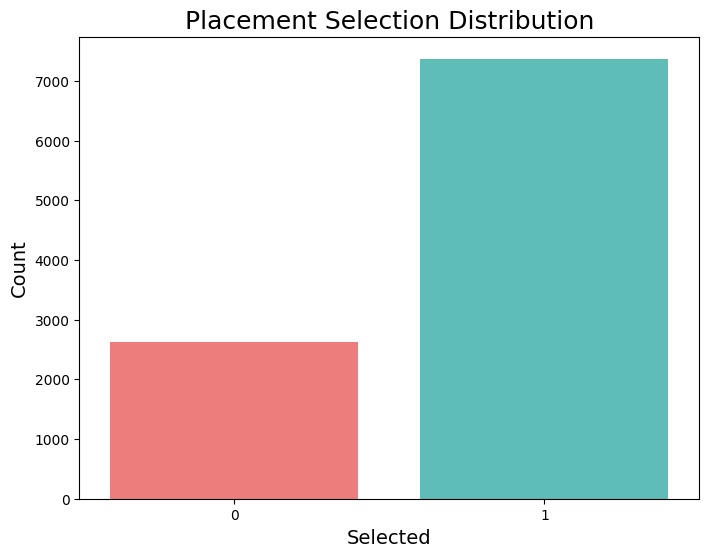

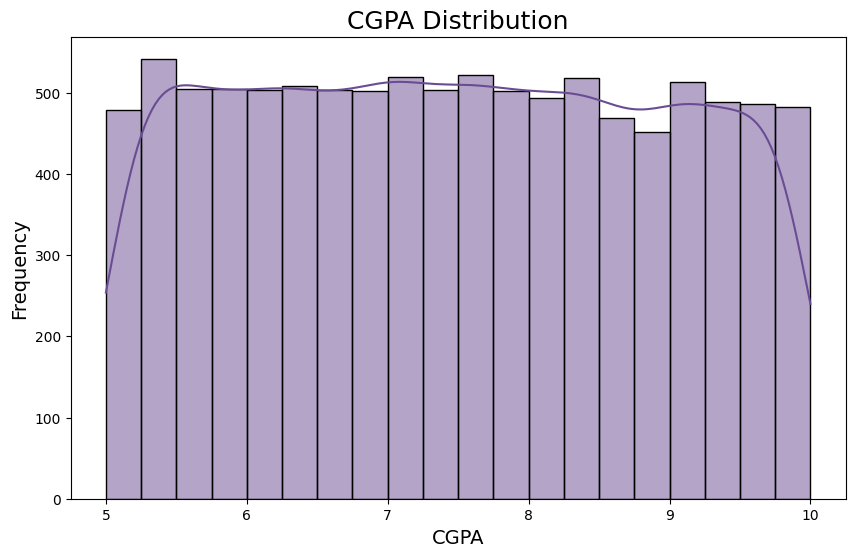

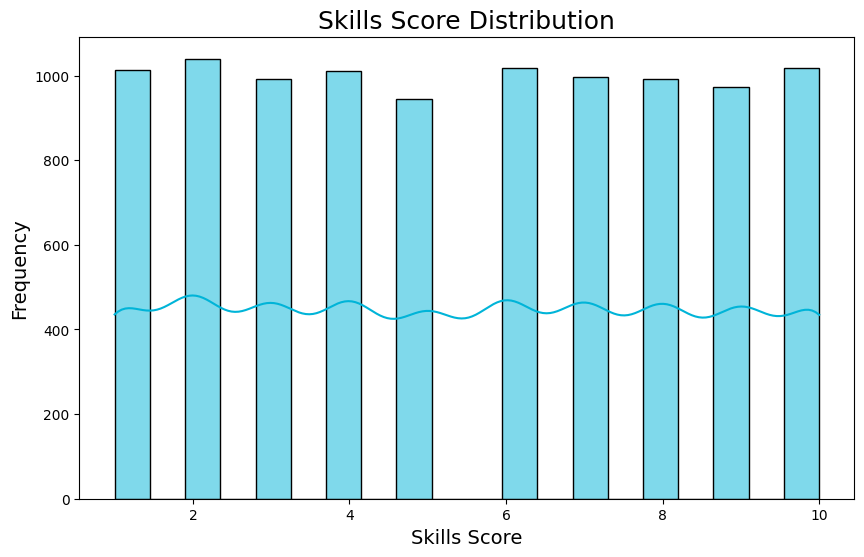

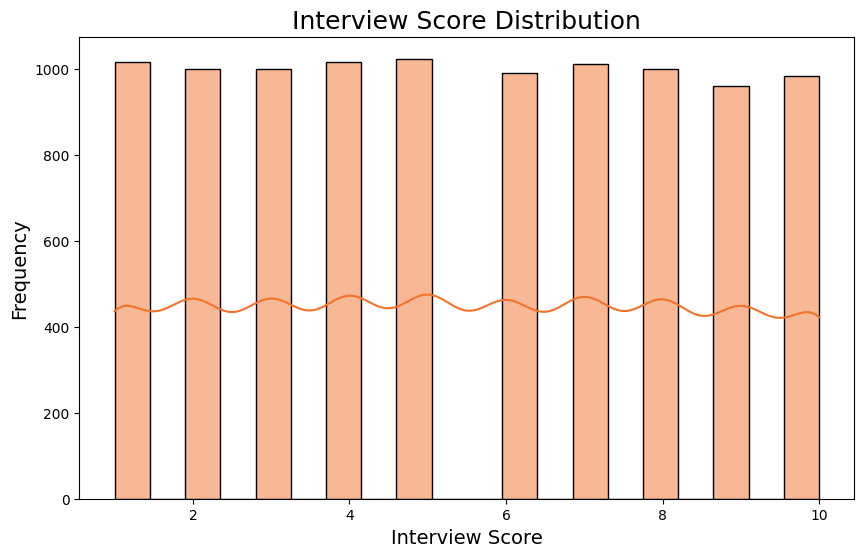

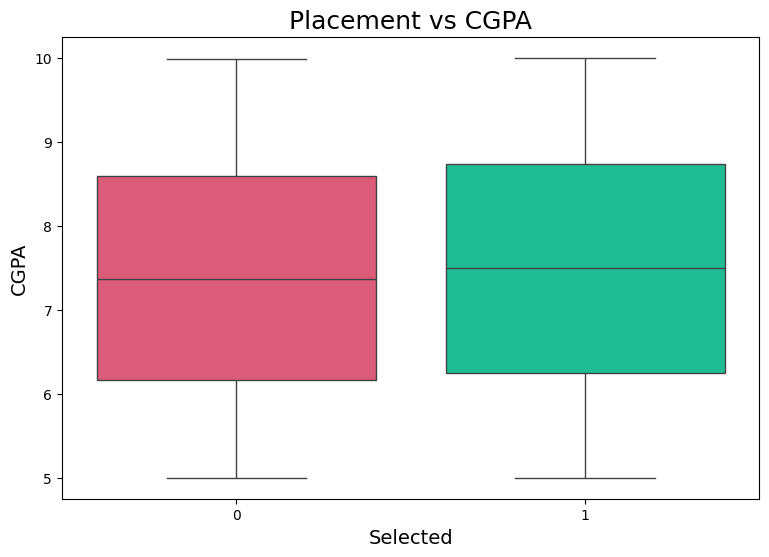

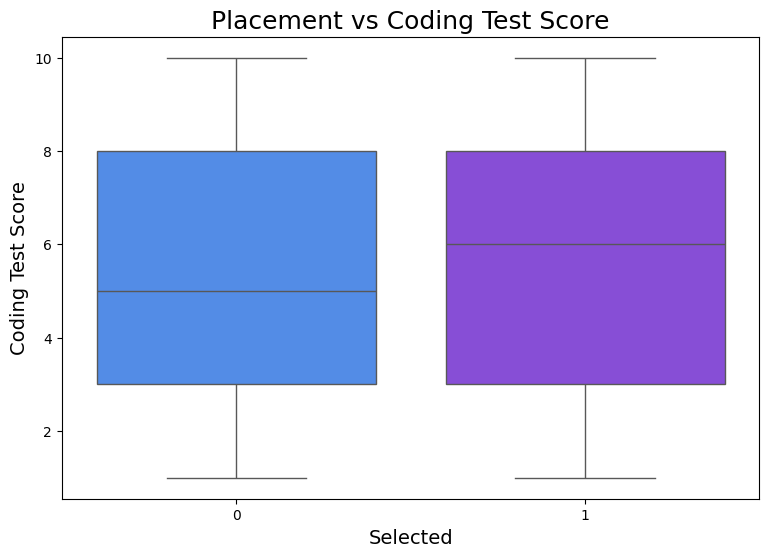

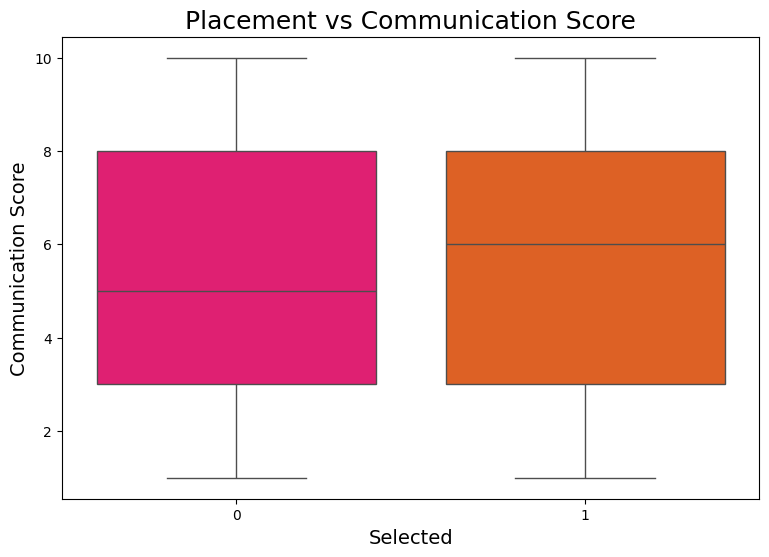

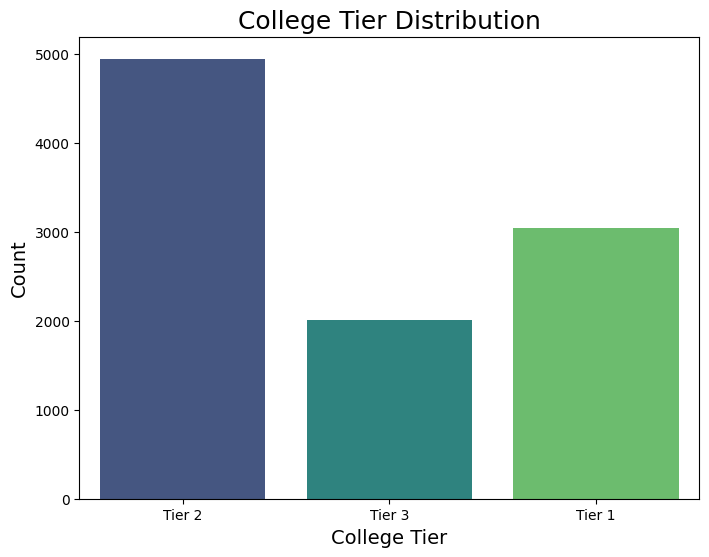

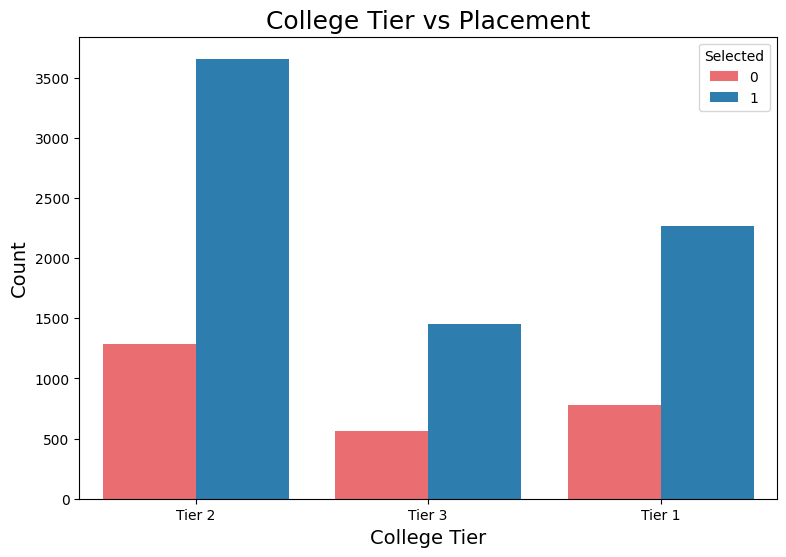

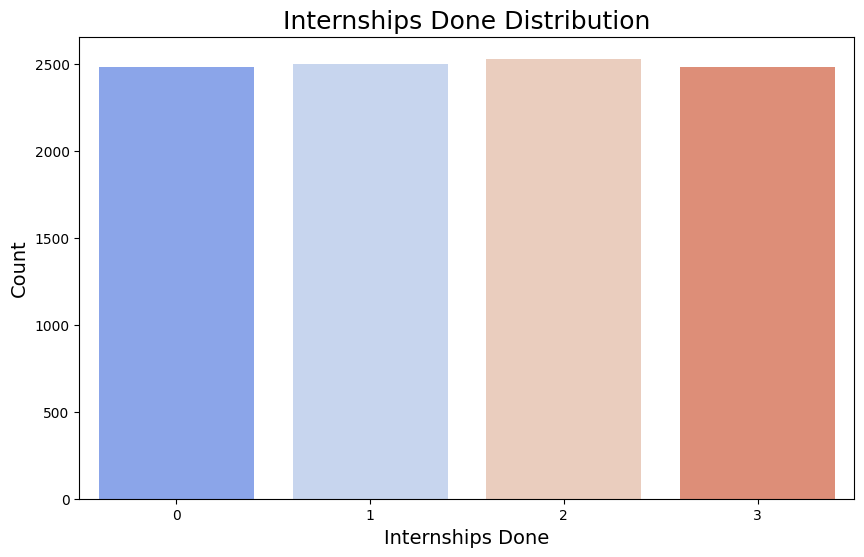

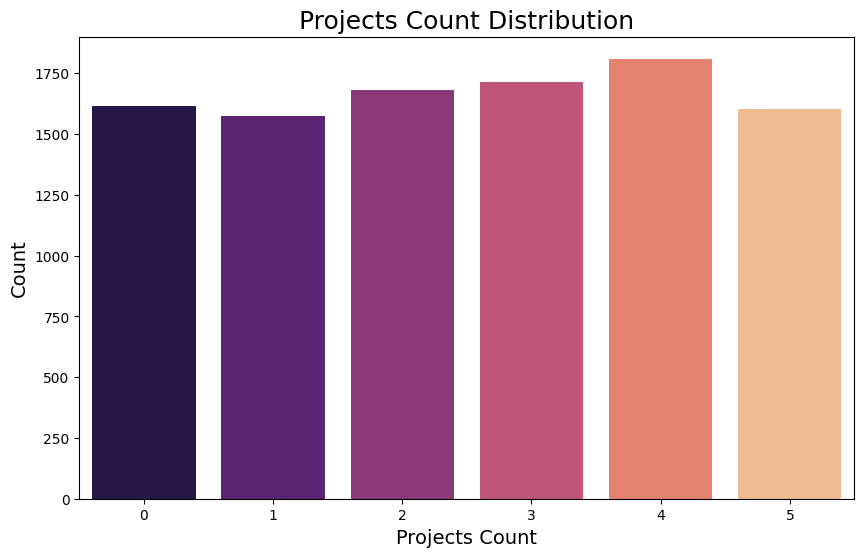

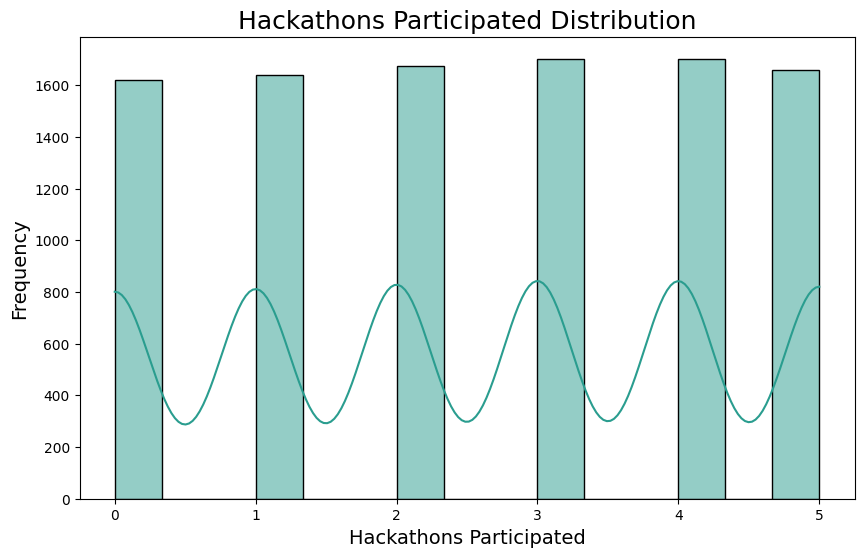

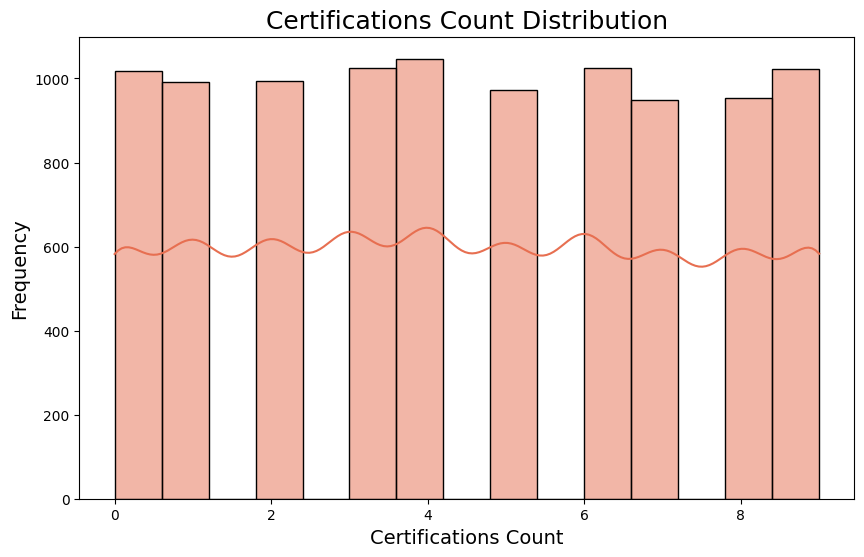

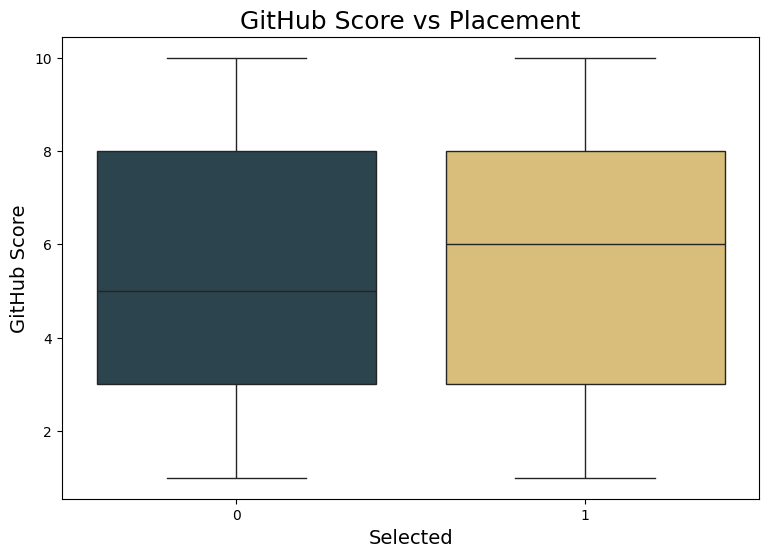

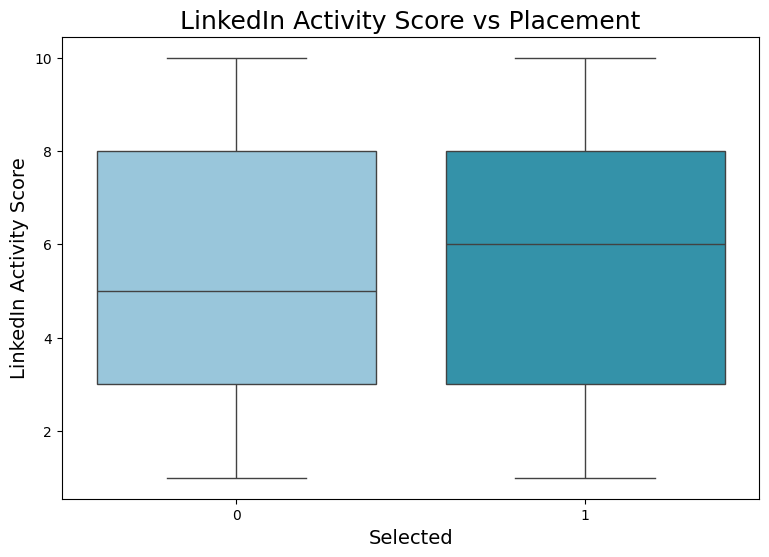

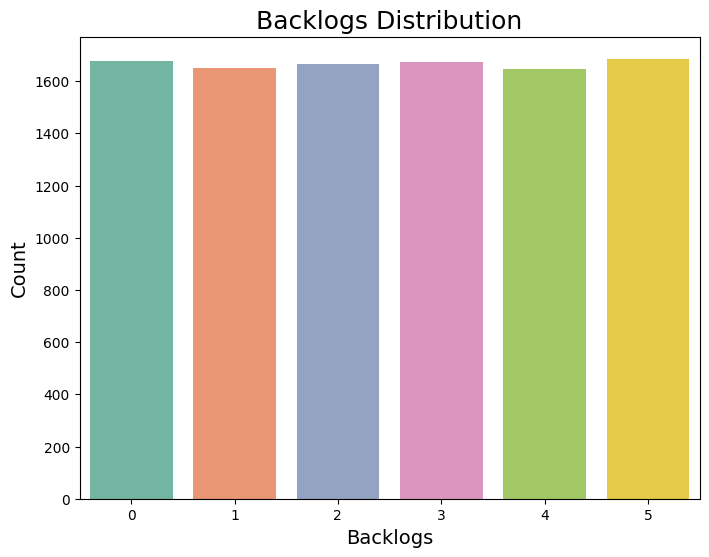

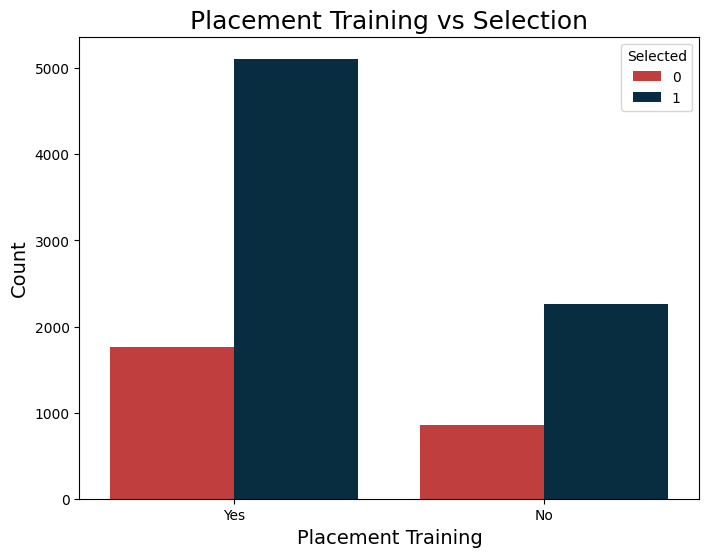

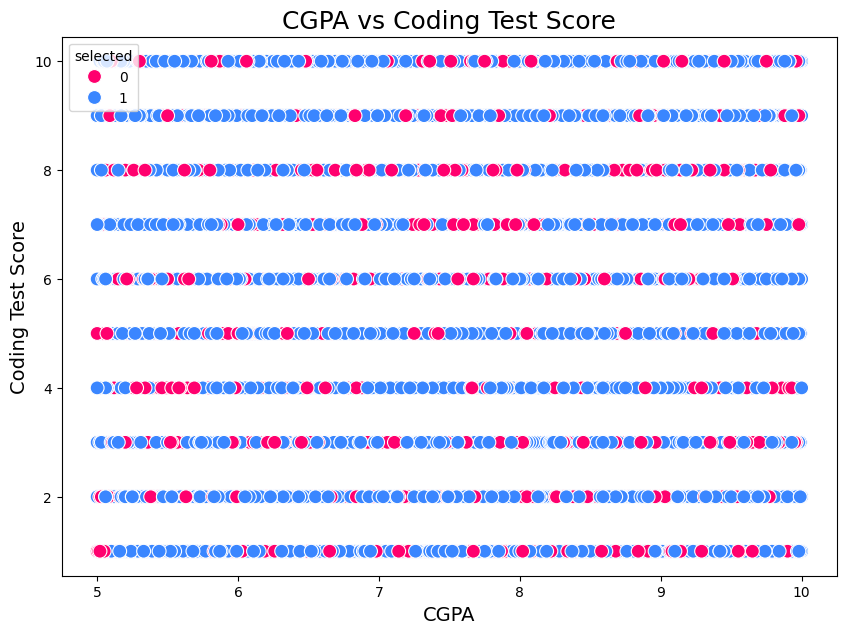

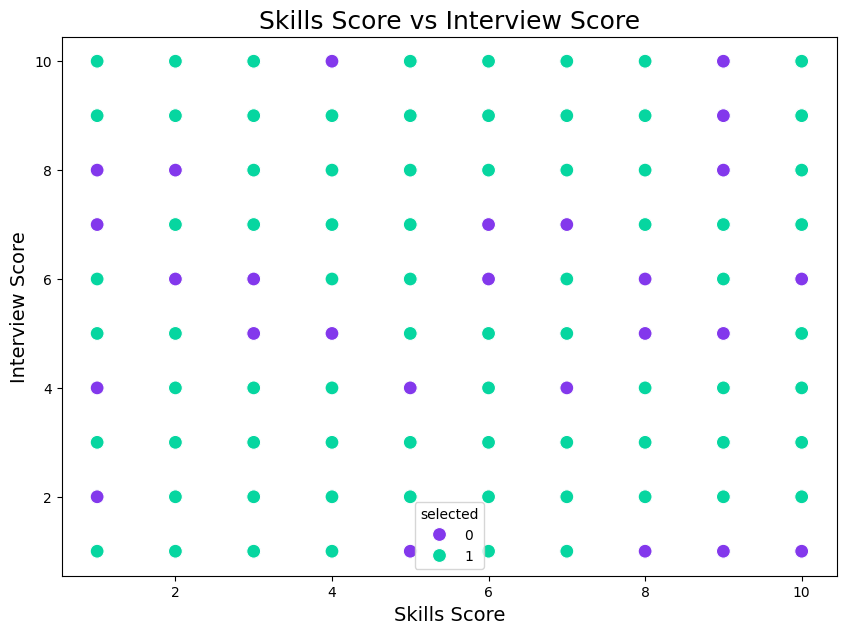

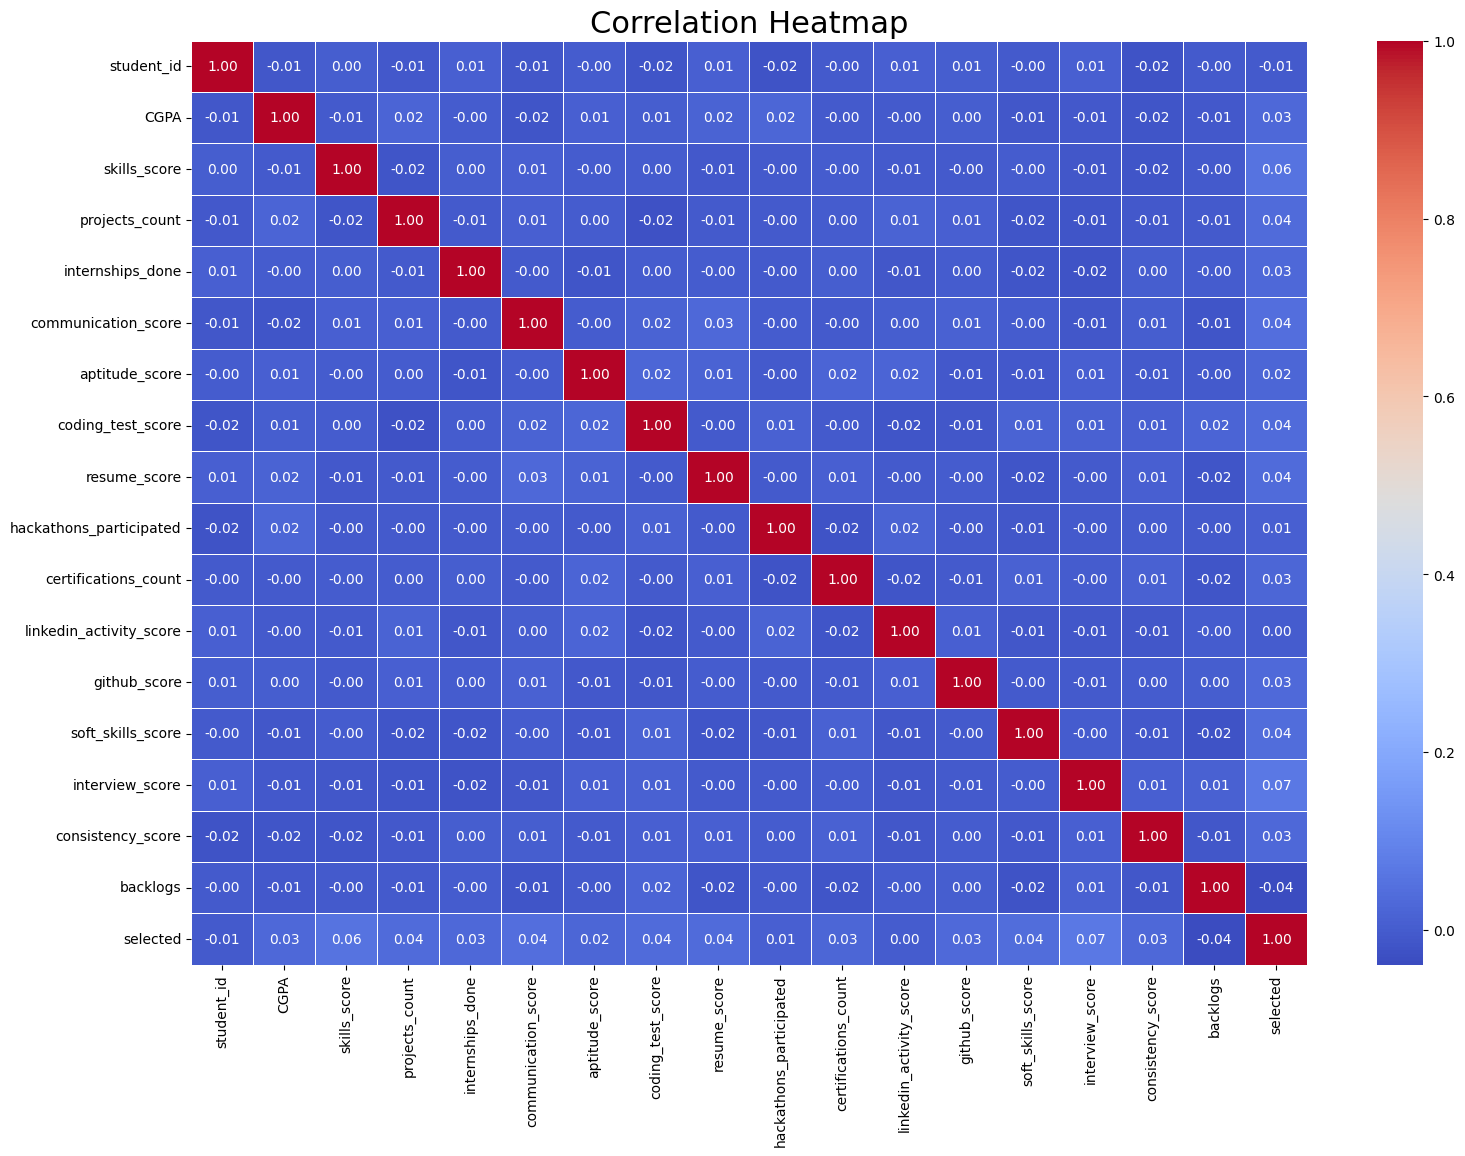

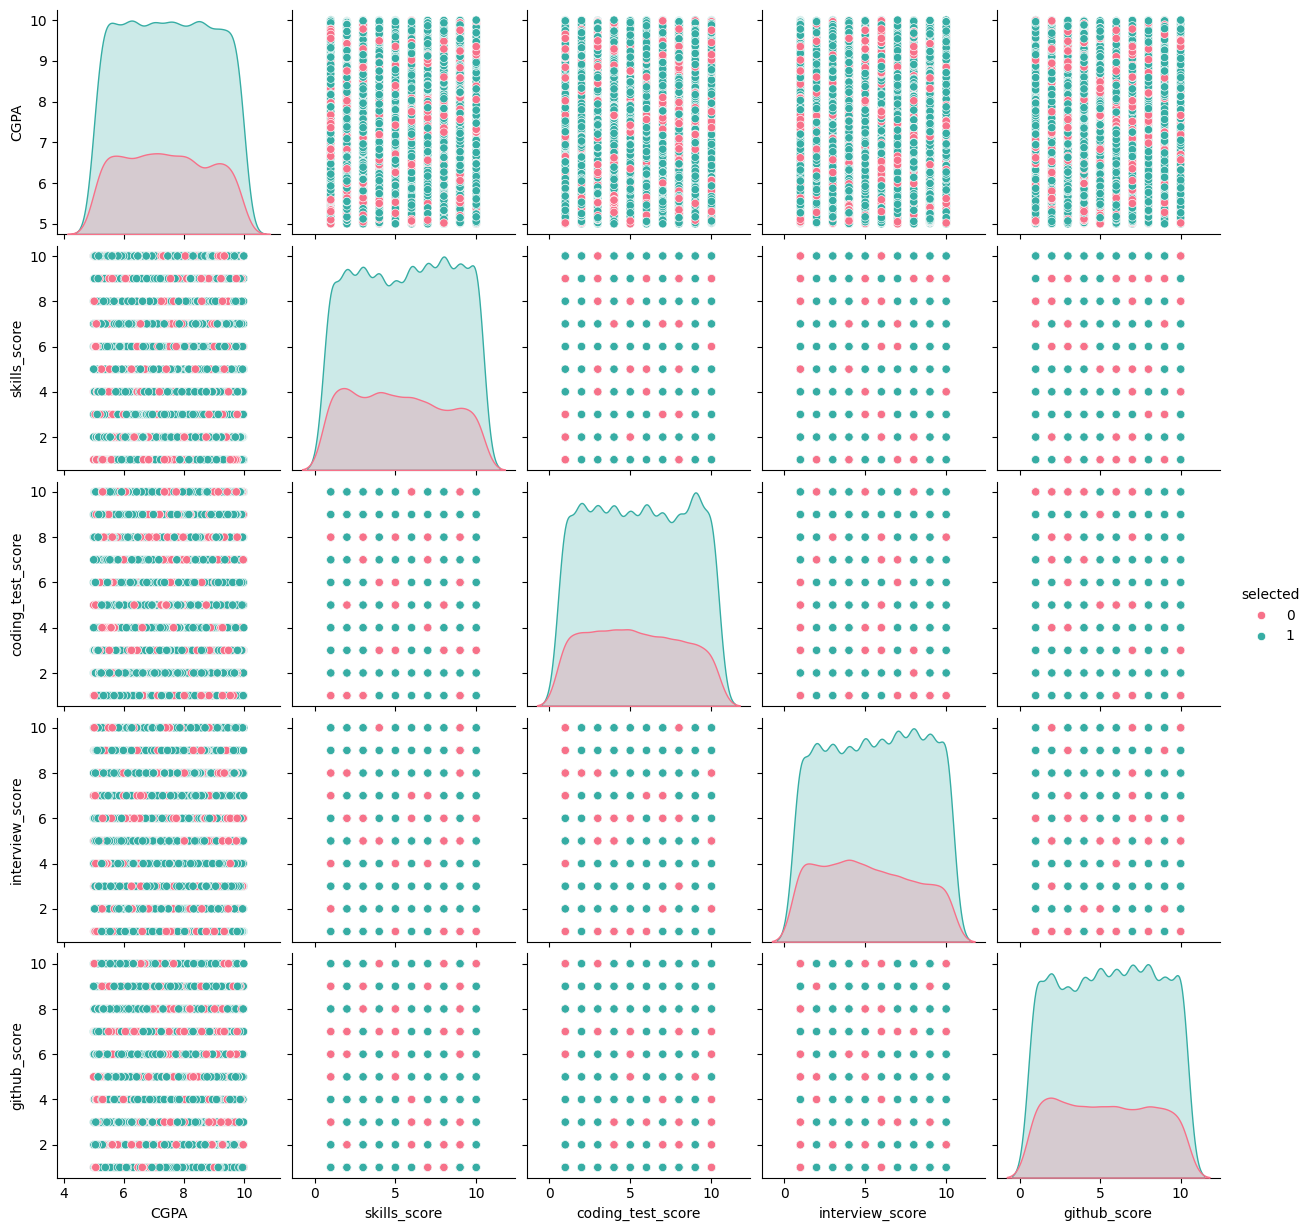

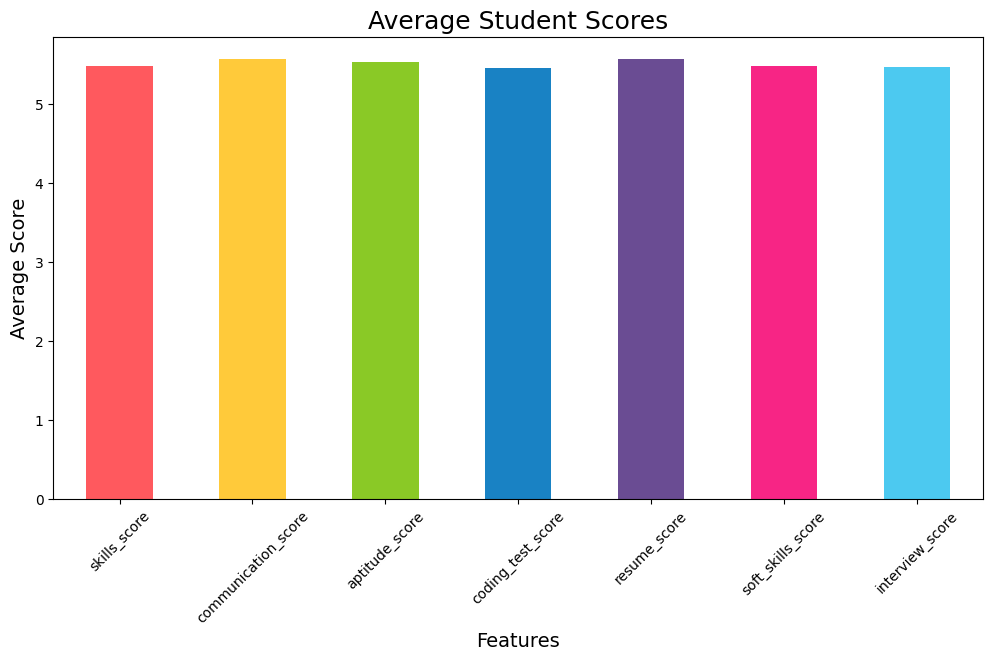

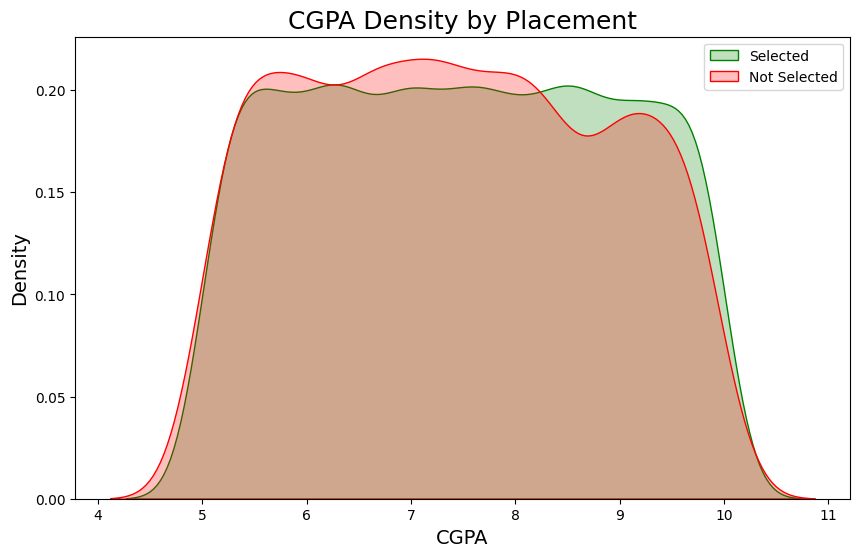

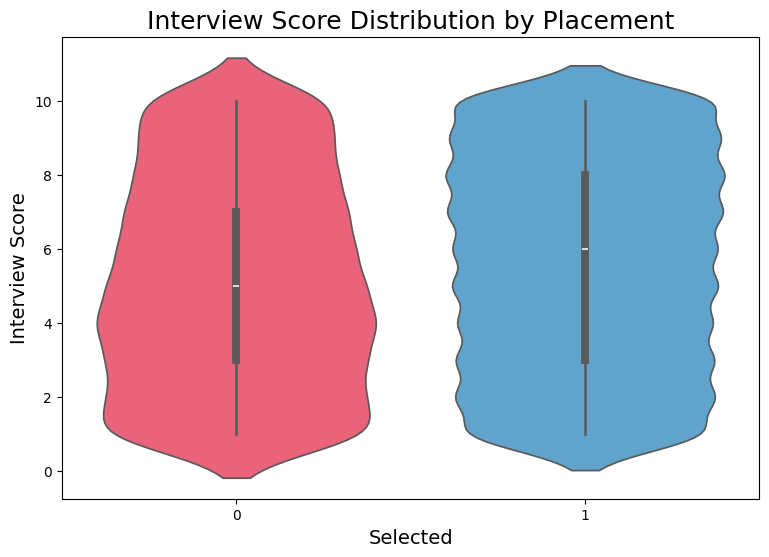

In [14]:
# =========================================================
# 1. TARGET VARIABLE DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,6))

colors = ["#ff6b6b", "#4ecdc4"]

sns.countplot(
    x='selected',
    data=df,
    palette=colors
)

plt.title("Placement Selection Distribution", fontsize=18)
plt.xlabel("Selected", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.show()

# =========================================================
# 2. CGPA DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['CGPA'],
    bins=20,
    kde=True,
    color="#6a4c93"
)

plt.title("CGPA Distribution", fontsize=18)
plt.xlabel("CGPA", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()

# =========================================================
# 3. SKILLS SCORE DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['skills_score'],
    bins=20,
    kde=True,
    color="#00b4d8"
)

plt.title("Skills Score Distribution", fontsize=18)
plt.xlabel("Skills Score", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()

# =========================================================
# 4. INTERVIEW SCORE DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['interview_score'],
    bins=20,
    kde=True,
    color="#f3722c"
)

plt.title("Interview Score Distribution", fontsize=18)
plt.xlabel("Interview Score", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()

# =========================================================
# 5. PLACEMENT VS CGPA
# =========================================================

plt.figure(figsize=(9,6))

sns.boxplot(
    x='selected',
    y='CGPA',
    data=df,
    palette=["#ef476f", "#06d6a0"]
)

plt.title("Placement vs CGPA", fontsize=18)
plt.xlabel("Selected", fontsize=14)
plt.ylabel("CGPA", fontsize=14)

plt.show()

# =========================================================
# 6. PLACEMENT VS CODING TEST SCORE
# =========================================================

plt.figure(figsize=(9,6))

sns.boxplot(
    x='selected',
    y='coding_test_score',
    data=df,
    palette=["#3a86ff", "#8338ec"]
)

plt.title("Placement vs Coding Test Score", fontsize=18)
plt.xlabel("Selected", fontsize=14)
plt.ylabel("Coding Test Score", fontsize=14)

plt.show()

# =========================================================
# 7. PLACEMENT VS COMMUNICATION SCORE
# =========================================================

plt.figure(figsize=(9,6))

sns.boxplot(
    x='selected',
    y='communication_score',
    data=df,
    palette=["#ff006e", "#fb5607"]
)

plt.title("Placement vs Communication Score", fontsize=18)
plt.xlabel("Selected", fontsize=14)
plt.ylabel("Communication Score", fontsize=14)

plt.show()

# =========================================================
# 8. COLLEGE TIER DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,6))

sns.countplot(
    x='college_tier',
    data=df,
    palette="viridis"
)

plt.title("College Tier Distribution", fontsize=18)
plt.xlabel("College Tier", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.show()

# =========================================================
# 9. COLLEGE TIER VS SELECTION
# =========================================================

plt.figure(figsize=(9,6))

sns.countplot(
    x='college_tier',
    hue='selected',
    data=df,
    palette=["#ff595e", "#1982c4"]
)

plt.title("College Tier vs Placement", fontsize=18)
plt.xlabel("College Tier", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.legend(title="Selected")

plt.show()

# =========================================================
# 10. INTERNSHIPS DONE DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,6))

sns.countplot(
    x='internships_done',
    data=df,
    palette="coolwarm"
)

plt.title("Internships Done Distribution", fontsize=18)
plt.xlabel("Internships Done", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.show()

# =========================================================
# 11. PROJECTS COUNT DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,6))

sns.countplot(
    x='projects_count',
    data=df,
    palette="magma"
)

plt.title("Projects Count Distribution", fontsize=18)
plt.xlabel("Projects Count", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.show()

# =========================================================
# 12. HACKATHONS PARTICIPATED
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['hackathons_participated'],
    bins=15,
    kde=True,
    color="#2a9d8f"
)

plt.title("Hackathons Participated Distribution", fontsize=18)
plt.xlabel("Hackathons Participated", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()

# =========================================================
# 13. CERTIFICATIONS DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['certifications_count'],
    bins=15,
    kde=True,
    color="#e76f51"
)

plt.title("Certifications Count Distribution", fontsize=18)
plt.xlabel("Certifications Count", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()

# =========================================================
# 14. GITHUB SCORE VS PLACEMENT
# =========================================================

plt.figure(figsize=(9,6))

sns.boxplot(
    x='selected',
    y='github_score',
    data=df,
    palette=["#264653", "#e9c46a"]
)

plt.title("GitHub Score vs Placement", fontsize=18)
plt.xlabel("Selected", fontsize=14)
plt.ylabel("GitHub Score", fontsize=14)

plt.show()

# =========================================================
# 15. LINKEDIN ACTIVITY SCORE VS PLACEMENT
# =========================================================

plt.figure(figsize=(9,6))

sns.boxplot(
    x='selected',
    y='linkedin_activity_score',
    data=df,
    palette=["#8ecae6", "#219ebc"]
)

plt.title("LinkedIn Activity Score vs Placement", fontsize=18)
plt.xlabel("Selected", fontsize=14)
plt.ylabel("LinkedIn Activity Score", fontsize=14)

plt.show()

# =========================================================
# 16. BACKLOGS DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,6))

sns.countplot(
    x='backlogs',
    data=df,
    palette="Set2"
)

plt.title("Backlogs Distribution", fontsize=18)
plt.xlabel("Backlogs", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.show()

# =========================================================
# 17. PLACEMENT TRAINING VS SELECTION
# =========================================================

plt.figure(figsize=(8,6))

sns.countplot(
    x='placement_training',
    hue='selected',
    data=df,
    palette=["#d62828", "#003049"]
)

plt.title("Placement Training vs Selection", fontsize=18)
plt.xlabel("Placement Training", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.legend(title="Selected")

plt.show()

# =========================================================
# 18. SCATTERPLOT - CGPA VS CODING SCORE
# =========================================================

plt.figure(figsize=(10,7))

sns.scatterplot(
    x='CGPA',
    y='coding_test_score',
    hue='selected',
    data=df,
    palette=["#ff006e", "#3a86ff"],
    s=100
)

plt.title("CGPA vs Coding Test Score", fontsize=18)
plt.xlabel("CGPA", fontsize=14)
plt.ylabel("Coding Test Score", fontsize=14)

plt.show()

# =========================================================
# 19. SCATTERPLOT - SKILLS SCORE VS INTERVIEW SCORE
# =========================================================

plt.figure(figsize=(10,7))

sns.scatterplot(
    x='skills_score',
    y='interview_score',
    hue='selected',
    data=df,
    palette=["#8338ec", "#06d6a0"],
    s=100
)

plt.title("Skills Score vs Interview Score", fontsize=18)
plt.xlabel("Skills Score", fontsize=14)
plt.ylabel("Interview Score", fontsize=14)

plt.show()

# =========================================================
# 20. CORRELATION HEATMAP
# =========================================================

# Remove student_id if not useful
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(18,12))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=22)

plt.show()

# =========================================================
# 21. PAIRPLOT
# =========================================================

selected_columns = [
    'CGPA',
    'skills_score',
    'coding_test_score',
    'interview_score',
    'github_score',
    'selected'
]

sns.pairplot(
    df[selected_columns],
    hue='selected',
    palette="husl"
)

plt.show()

# =========================================================
# 22. AVERAGE SCORES COMPARISON
# =========================================================

avg_scores = df[[
    'skills_score',
    'communication_score',
    'aptitude_score',
    'coding_test_score',
    'resume_score',
    'soft_skills_score',
    'interview_score'
]].mean()

plt.figure(figsize=(12,6))

avg_scores.plot(
    kind='bar',
    color=[
        '#ff595e',
        '#ffca3a',
        '#8ac926',
        '#1982c4',
        '#6a4c93',
        '#f72585',
        '#4cc9f0'
    ]
)

plt.title("Average Student Scores", fontsize=18)
plt.xlabel("Features", fontsize=14)
plt.ylabel("Average Score", fontsize=14)

plt.xticks(rotation=45)

plt.show()

# =========================================================
# 23. KDE PLOT - SELECTED VS NOT SELECTED
# =========================================================

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df[df['selected']==1]['CGPA'],
    label='Selected',
    fill=True,
    color='green'
)

sns.kdeplot(
    data=df[df['selected']==0]['CGPA'],
    label='Not Selected',
    fill=True,
    color='red'
)

plt.title("CGPA Density by Placement", fontsize=18)
plt.xlabel("CGPA", fontsize=14)
plt.ylabel("Density", fontsize=14)

plt.legend()

plt.show()

# =========================================================
# 24. VIOLIN PLOT
# =========================================================

plt.figure(figsize=(9,6))

sns.violinplot(
    x='selected',
    y='interview_score',
    data=df,
    palette=["#ff4d6d", "#4ea8de"]
)

plt.title("Interview Score Distribution by Placement", fontsize=18)
plt.xlabel("Selected", fontsize=14)
plt.ylabel("Interview Score", fontsize=14)

plt.show()

## Feature engineering

extracurricular Encoded
college_tier Encoded
placement_training Encoded

================ FEATURES ================

Index(['CGPA', 'skills_score', 'projects_count', 'internships_done',
       'communication_score', 'aptitude_score', 'coding_test_score',
       'resume_score', 'extracurricular', 'college_tier',
       'hackathons_participated', 'certifications_count',
       'linkedin_activity_score', 'github_score', 'soft_skills_score',
       'interview_score', 'consistency_score', 'backlogs',
       'placement_training'],
      dtype='object')

================ TARGET ================

0    1
1    1
2    1
3    1
4    1
Name: selected, dtype: int64

================ TRAIN TEST SHAPES ================

X_train shape : (8000, 19)
X_test shape  : (2000, 19)
y_train shape : (8000,)
y_test shape  : (2000,)

MODEL : Logistic Regression

Accuracy  : 0.7370
Precision : 0.7376
Recall    : 0.9986
F1 Score  : 0.8485
ROC AUC   : 0.6020

Classification Report

              precision    recall  

<Figure size 1200x800 with 0 Axes>

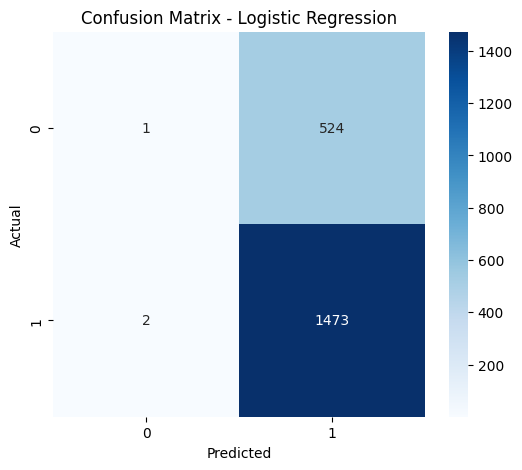


MODEL : Decision Tree

Accuracy  : 0.7315
Precision : 0.7378
Recall    : 0.9864
F1 Score  : 0.8442
ROC AUC   : 0.5535

Classification Report

              precision    recall  f1-score   support

           0       0.29      0.02      0.03       525
           1       0.74      0.99      0.84      1475

    accuracy                           0.73      2000
   macro avg       0.51      0.50      0.44      2000
weighted avg       0.62      0.73      0.63      2000



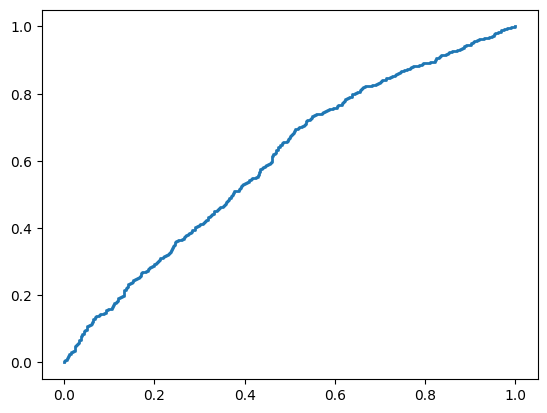

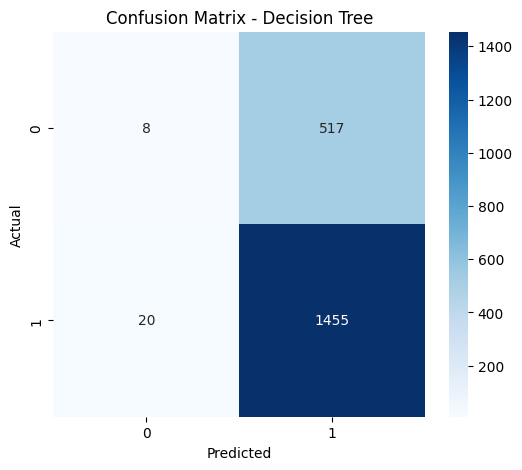


MODEL : Random Forest

Accuracy  : 0.7360
Precision : 0.7371
Recall    : 0.9980
F1 Score  : 0.8479
ROC AUC   : 0.5465

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       525
           1       0.74      1.00      0.85      1475

    accuracy                           0.74      2000
   macro avg       0.37      0.50      0.42      2000
weighted avg       0.54      0.74      0.63      2000



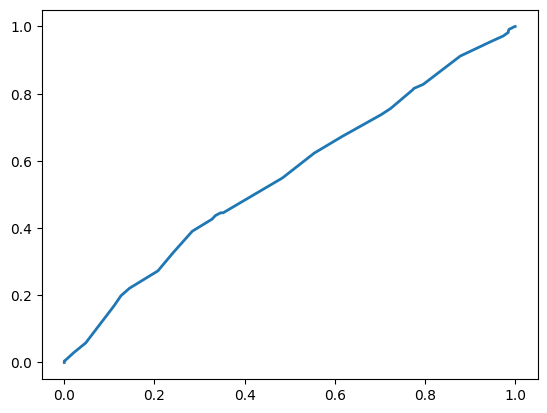

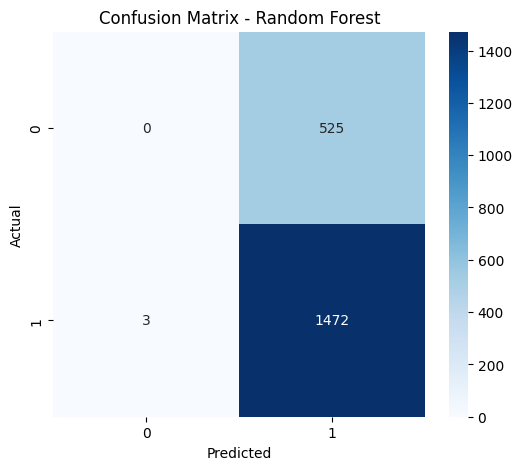


MODEL : Gradient Boosting

Accuracy  : 0.7360
Precision : 0.7373
Recall    : 0.9973
F1 Score  : 0.8478
ROC AUC   : 0.5665

Classification Report

              precision    recall  f1-score   support

           0       0.20      0.00      0.00       525
           1       0.74      1.00      0.85      1475

    accuracy                           0.74      2000
   macro avg       0.47      0.50      0.43      2000
weighted avg       0.60      0.74      0.63      2000



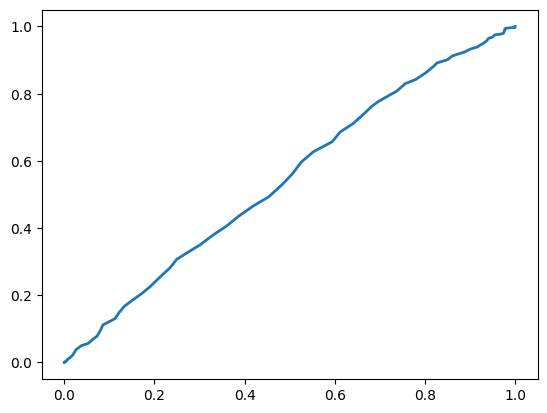

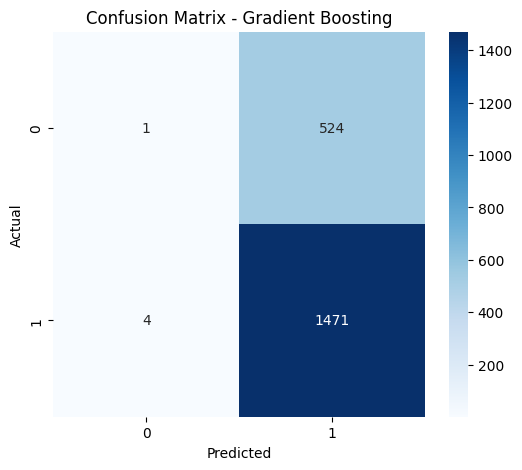


MODEL : KNN

Accuracy  : 0.6780
Precision : 0.7365
Recall    : 0.8773
F1 Score  : 0.8007
ROC AUC   : 0.5045

Classification Report

              precision    recall  f1-score   support

           0       0.26      0.12      0.16       525
           1       0.74      0.88      0.80      1475

    accuracy                           0.68      2000
   macro avg       0.50      0.50      0.48      2000
weighted avg       0.61      0.68      0.63      2000



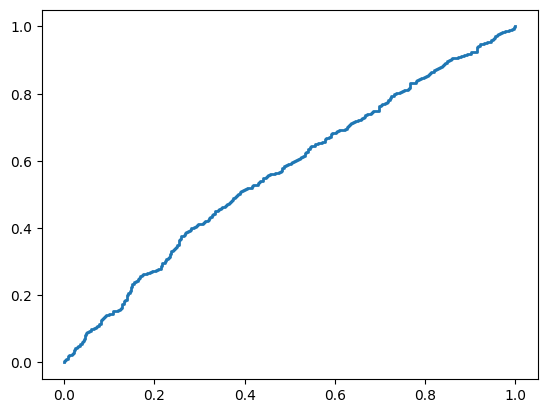

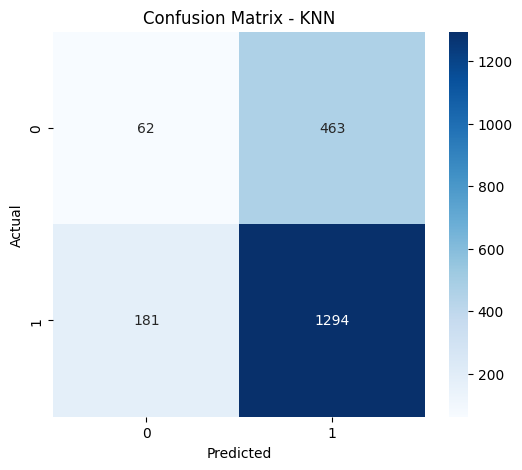


MODEL : SVM

Accuracy  : 0.7375
Precision : 0.7375
Recall    : 1.0000
F1 Score  : 0.8489
ROC AUC   : 0.5204

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       525
           1       0.74      1.00      0.85      1475

    accuracy                           0.74      2000
   macro avg       0.37      0.50      0.42      2000
weighted avg       0.54      0.74      0.63      2000



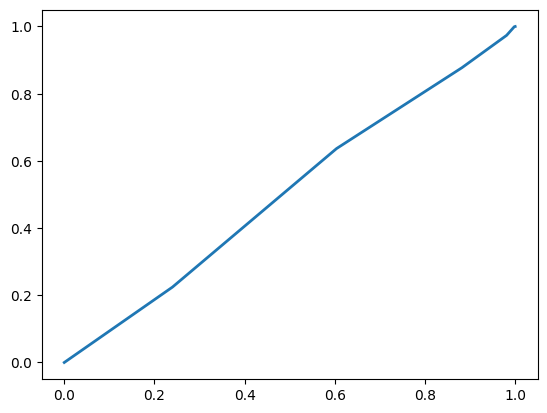

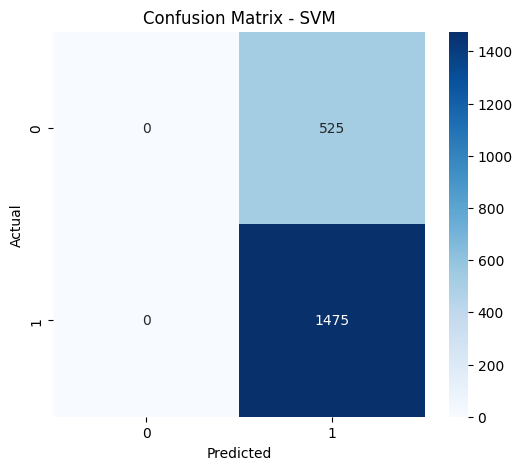


MODEL : Naive Bayes

Accuracy  : 0.7370
Precision : 0.7378
Recall    : 0.9980
F1 Score  : 0.8484
ROC AUC   : 0.6015

Classification Report

              precision    recall  f1-score   support

           0       0.40      0.00      0.01       525
           1       0.74      1.00      0.85      1475

    accuracy                           0.74      2000
   macro avg       0.57      0.50      0.43      2000
weighted avg       0.65      0.74      0.63      2000



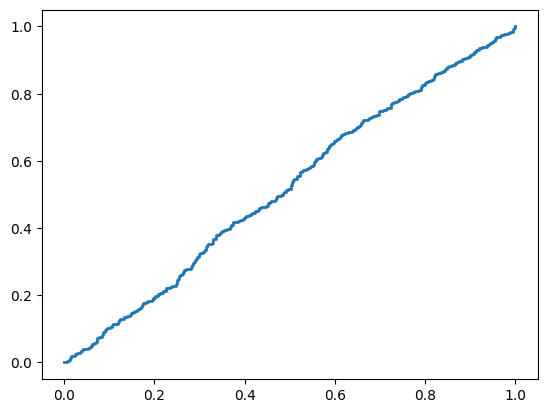

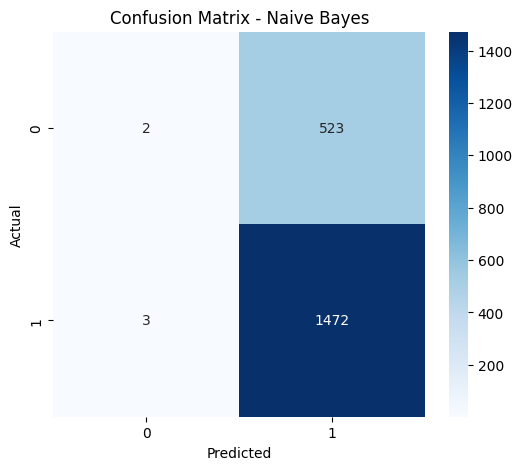

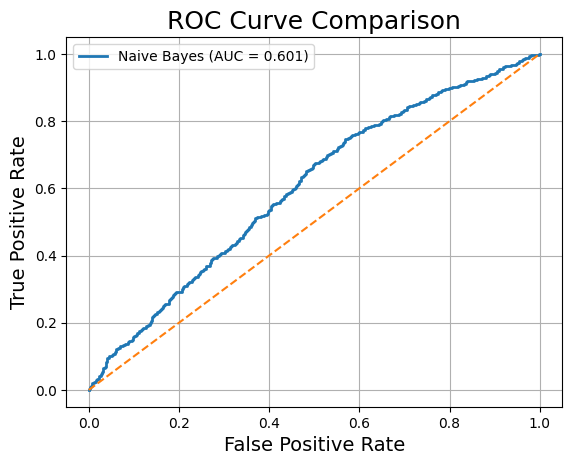


================ MODEL PERFORMANCE ================

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
5                  SVM    0.7375   0.737500  1.000000  0.848921  0.520360
6          Naive Bayes    0.7370   0.737845  0.997966  0.848415  0.601489
0  Logistic Regression    0.7370   0.737606  0.998644  0.848502  0.602040
3    Gradient Boosting    0.7360   0.737343  0.997288  0.847839  0.566502
2        Random Forest    0.7360   0.737106  0.997966  0.847926  0.546472
1        Decision Tree    0.7315   0.737830  0.986441  0.844212  0.553466
4                  KNN    0.6780   0.736483  0.877288  0.800743  0.504531


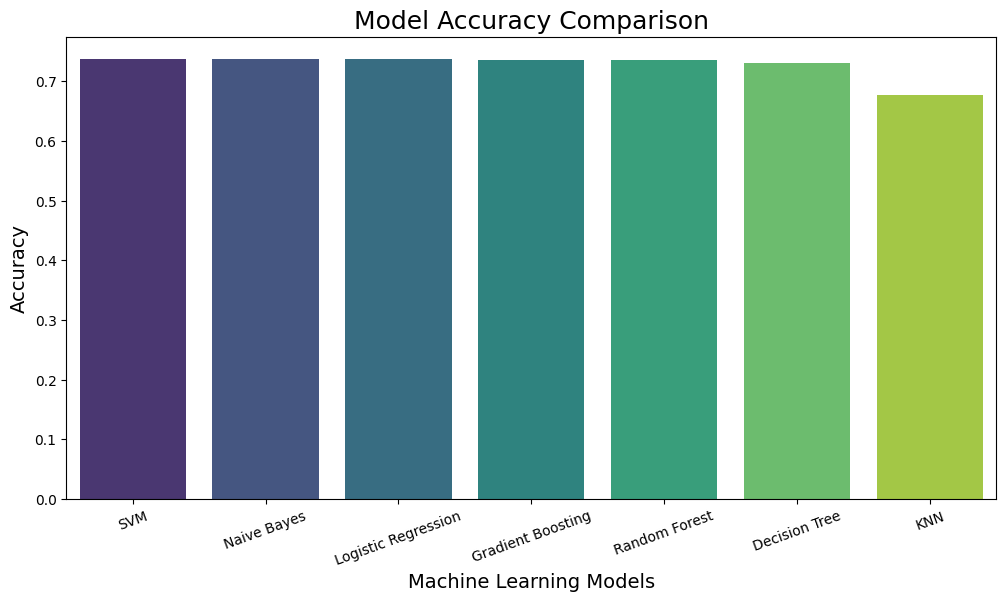

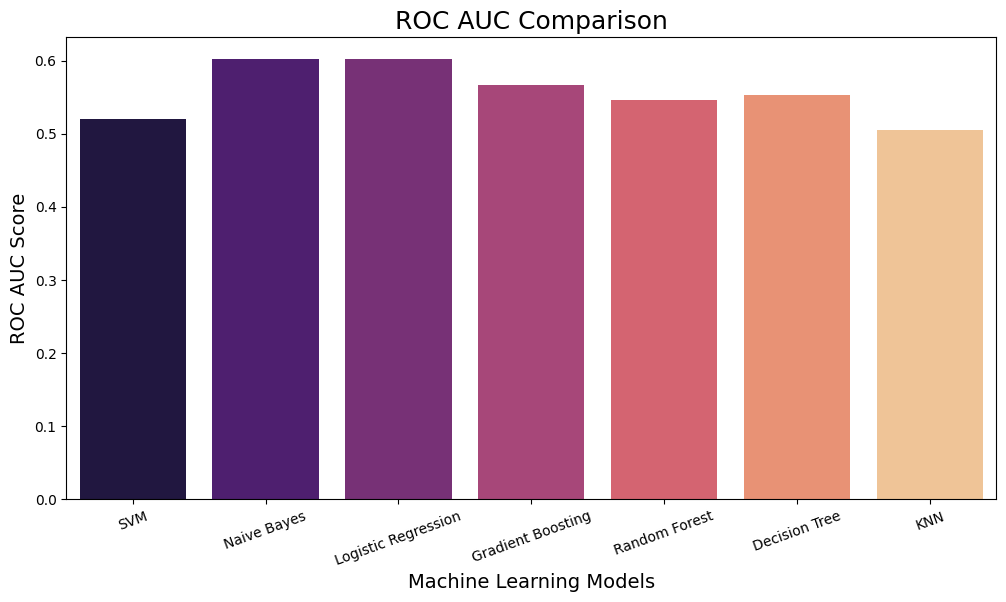


================ FEATURE IMPORTANCE ================

                    Feature  Importance
0                      CGPA    0.106958
5            aptitude_score    0.061814
12  linkedin_activity_score    0.061160
7              resume_score    0.060861
13             github_score    0.060775
16        consistency_score    0.060042
14        soft_skills_score    0.059973
11     certifications_count    0.059786
4       communication_score    0.059571
6         coding_test_score    0.059098
15          interview_score    0.058151
1              skills_score    0.057717
10  hackathons_participated    0.046746
17                 backlogs    0.045869
2            projects_count    0.045232
3          internships_done    0.035734
9              college_tier    0.027829
8           extracurricular    0.016414
18       placement_training    0.016269


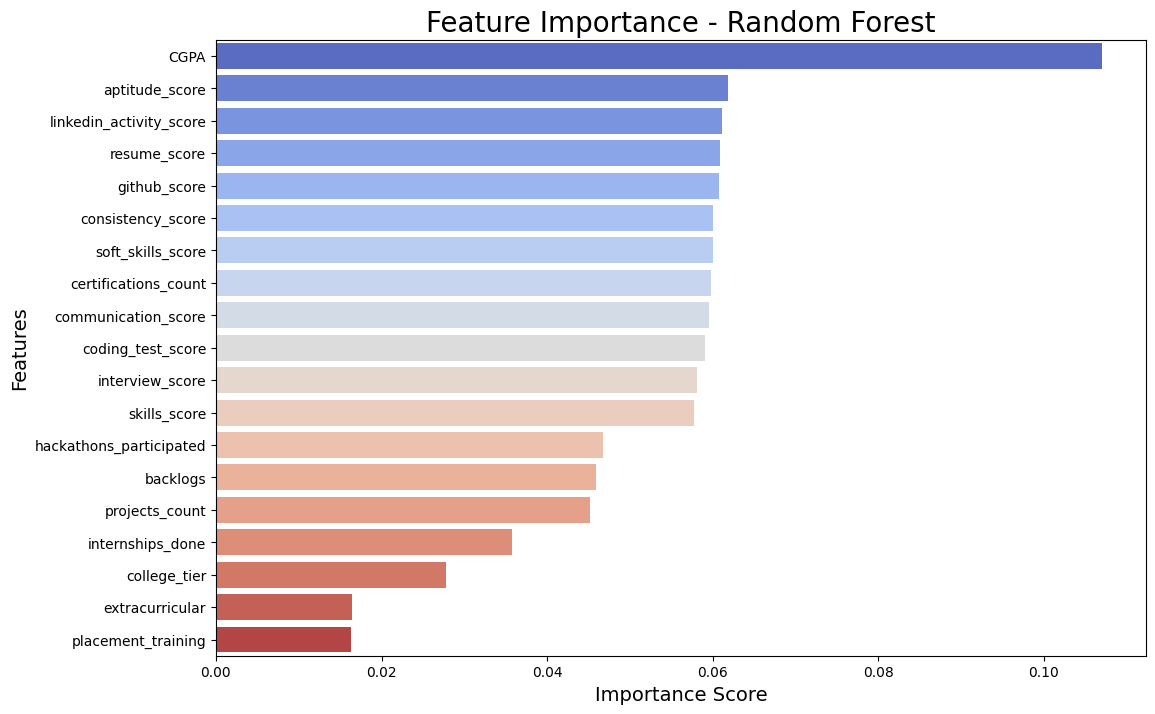


================ BEST MODEL ================

Best Model : SVM
Best Accuracy : 0.7375

================ SAMPLE PREDICTIONS ================

Predictions : [1 1 1 1 1]

Actual Values : [1 1 1 0 0]

STUDENT PLACEMENT ML PROJECT COMPLETED SUCCESSFULLY


In [15]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


# student_id is unique, not useful for prediction
df.drop("student_id", axis=1, inplace=True)

label_encoders = {}

categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col])
    
    label_encoders[col] = le
    
    print(f"{col} Encoded")

# =========================================================
# 6. DEFINE FEATURES AND TARGET
# =========================================================

X = df.drop("selected", axis=1)

y = df["selected"]

print("\n================ FEATURES ================\n")
print(X.columns)

print("\n================ TARGET ================\n")
print(y.head())

# =========================================================
# 7. TRAIN TEST SPLIT
# =========================================================
# No data leakage because splitting is done
# BEFORE scaling.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n================ TRAIN TEST SHAPES ================\n")

print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

# =========================================================
# 8. FEATURE SCALING
# =========================================================
# IMPORTANT:
# Fit scaler ONLY on training data
# to avoid DATA LEAKAGE.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# =========================================================
# 9. MACHINE LEARNING MODELS
# =========================================================

models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "Naive Bayes": GaussianNB()
}

# =========================================================
# 10. TRAINING AND EVALUATION
# =========================================================

results = []

plt.figure(figsize=(12,8))

for name, model in models.items():

    print("\n===================================================")
    print(f"MODEL : {name}")
    print("===================================================\n")

    # =====================================================
    # USE SCALED DATA FOR THESE MODELS
    # =====================================================

    if name in ["Logistic Regression", "KNN", "SVM", "Naive Bayes"]:

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

        y_prob = model.predict_proba(X_test_scaled)[:,1]

    else:

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        y_prob = model.predict_proba(X_test)[:,1]

    # =====================================================
    # METRICS
    # =====================================================

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    # =====================================================
    # STORE RESULTS
    # =====================================================

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

    # =====================================================
    # PRINT SCORES
    # =====================================================

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    print("\nClassification Report\n")

    print(classification_report(y_test, y_pred))

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"Confusion Matrix - {name}")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # =====================================================
    # ROC CURVE
    # =====================================================

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# =========================================================
# 11. FINAL ROC CURVE
# =========================================================

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.title("ROC Curve Comparison", fontsize=18)

plt.xlabel("False Positive Rate", fontsize=14)

plt.ylabel("True Positive Rate", fontsize=14)

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# 12. RESULTS TABLE
# =========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

# =========================================================
# 13. SORT RESULTS
# =========================================================

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n================ MODEL PERFORMANCE ================\n")

print(results_df)

# =========================================================
# 14. BARPLOT - MODEL ACCURACY
# =========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df,
    palette="viridis"
)

plt.title("Model Accuracy Comparison", fontsize=18)

plt.xlabel("Machine Learning Models", fontsize=14)

plt.ylabel("Accuracy", fontsize=14)

plt.xticks(rotation=20)

plt.show()

# =========================================================
# 15. BARPLOT - ROC AUC
# =========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x="Model",
    y="ROC AUC",
    data=results_df,
    palette="magma"
)

plt.title("ROC AUC Comparison", fontsize=18)

plt.xlabel("Machine Learning Models", fontsize=14)

plt.ylabel("ROC AUC Score", fontsize=14)

plt.xticks(rotation=20)

plt.show()

# =========================================================
# 16. FEATURE IMPORTANCE - RANDOM FOREST
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

importance = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": importance

})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n================ FEATURE IMPORTANCE ================\n")

print(feature_importance_df)

# =========================================================
# 17. FEATURE IMPORTANCE VISUALIZATION
# =========================================================

plt.figure(figsize=(12,8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df,
    palette="coolwarm"
)

plt.title("Feature Importance - Random Forest", fontsize=20)

plt.xlabel("Importance Score", fontsize=14)

plt.ylabel("Features", fontsize=14)

plt.show()

# =========================================================
# 18. BEST MODEL
# =========================================================

best_model = results_df.iloc[0]

print("\n================ BEST MODEL ================\n")

print("Best Model :", best_model["Model"])

print("Best Accuracy :", round(best_model["Accuracy"],4))

# =========================================================
# 19. PREDICTION ON TEST SAMPLE
# =========================================================

sample_prediction = rf_model.predict(X_test.iloc[:5])

print("\n================ SAMPLE PREDICTIONS ================\n")

print("Predictions :", sample_prediction)

print("\nActual Values :", y_test.iloc[:5].values)

# =========================================================
# 20. COMPLETED
# =========================================================

print("\n===================================================")
print("STUDENT PLACEMENT ML PROJECT COMPLETED SUCCESSFULLY")
print("===================================================")

## Thank you...pls upvote!!!!!!!!!!